In [42]:
%matplotlib inline

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


In [43]:
trunk_x_0 = torch.tensor([[0, 0, 0.31]])
trunk_xd_0 = torch.zeros_like(trunk_x_0)
trunk_o_0 = torch.zeros_like(trunk_x_0)
trunk_od_0 = torch.zeros_like(trunk_x_0)

In [44]:
trunk_x_lo = torch.tensor([[0.1648, 0.0000, 0.3211]])
trunk_xd_lo = torch.tensor([[0.9, 0.0000, 1.3]])
trunk_o_lo = torch.tensor([[-0.0063,  0.1452,  0.0093]])
trunk_od_lo = torch.tensor([[-0.0542,  4, -0.0133]])
t_th = torch.tensor([[0.75,]])

# trunk_x_lo = torch.tensor([[0.1648, 0.0000, 0.3211]])
# trunk_xd_lo = torch.tensor([[0.9, 0.0000, 1.3]])
# trunk_o_lo = torch.tensor([[0,0,0]])
# trunk_od_lo = torch.tensor([[0,0,0]])
# t_th = torch.tensor([[0.75,]])

In [45]:
def BezierTrajectory(start: torch.Tensor, start_v: torch.Tensor, end: torch.Tensor, end_v: torch.Tensor, t_th: torch.Tensor, t_ex: float):

    w = torch.stack((
        start.unsqueeze(1),
        (((t_th / 3) * start_v) + start).unsqueeze(1),
        ((-(t_th / 3) * end_v) + end).unsqueeze(1),
        end.unsqueeze(1)), dim=2).squeeze()

    w = w.reshape(-1, 4, 3)

    w_d = torch.stack((
        ((3 / t_th) * (w[:, 1] - w[:, 0])).unsqueeze(1),
        ((3 / t_th) * (w[:, 2] - w[:, 1])).unsqueeze(1),
        ((3 / t_th) * (w[:, 3] - w[:, 2])).unsqueeze(1)), dim=2).squeeze()

    t = t_ex / t_th

    bezier_curve_3 = torch.cat((
        (1.0) * (t**0) * (1 - t)**(3 - 0),
        (3.0) * (t**1) * (1 - t)**(3 - 1),
        (3.0) * (t**2) * (1 - t)**(3 - 2),
        (1.0) * (t**3) * (1 - t)**(3 - 3),
    ), dim=-1)

    bezier_curve_2 = torch.cat((
        (1.0) * (t**0) * (1 - t)**(2 - 0),
        (2.0) * (t**1) * (1 - t)**(2 - 1),
        (1.0) * (t**2) * (1 - t)**(2 - 2),
    ), dim=-1)

    bezier_position = torch.cat((
        (w[..., 0] * bezier_curve_3).sum(dim=-1).reshape(-1, 1),
        (w[..., 1] * bezier_curve_3).sum(dim=-1).reshape(-1, 1),
        (w[..., 2] * bezier_curve_3).sum(dim=-1).reshape(-1, 1)), dim=1)

    bezier_velocity = torch.cat((
        (w_d[..., 0] * bezier_curve_2).sum(dim=-1).reshape(-1, 1),
        (w_d[..., 1] * bezier_curve_2).sum(dim=-1).reshape(-1, 1),
        (w_d[..., 2] * bezier_curve_2).sum(dim=-1).reshape(-1, 1)), dim=1)

    return bezier_position, bezier_velocity

In [46]:
max_time = t_th.item() + 0.005

pos_lin_vel = [BezierTrajectory(trunk_x_0, trunk_xd_0, trunk_x_lo, trunk_xd_lo, t_th, t) for t in torch.arange(0, max_time, 0.005*10)]
pos = torch.stack([val[0] for val in pos_lin_vel], dim=1)
lin_vel = torch.stack([val[1] for val in pos_lin_vel], dim=1)

orient_ang_vel = [BezierTrajectory(trunk_o_0, trunk_od_0, trunk_o_lo, trunk_od_lo, t_th, t) for t in torch.arange(0, max_time, 0.005*10)]
orient = torch.stack([val[0] for val in orient_ang_vel], dim=1)
ang_vel = torch.stack([val[1] for val in orient_ang_vel], dim=1)

In [47]:
pos.shape

torch.Size([1, 16, 3])

In [48]:
# %matplotlib tk

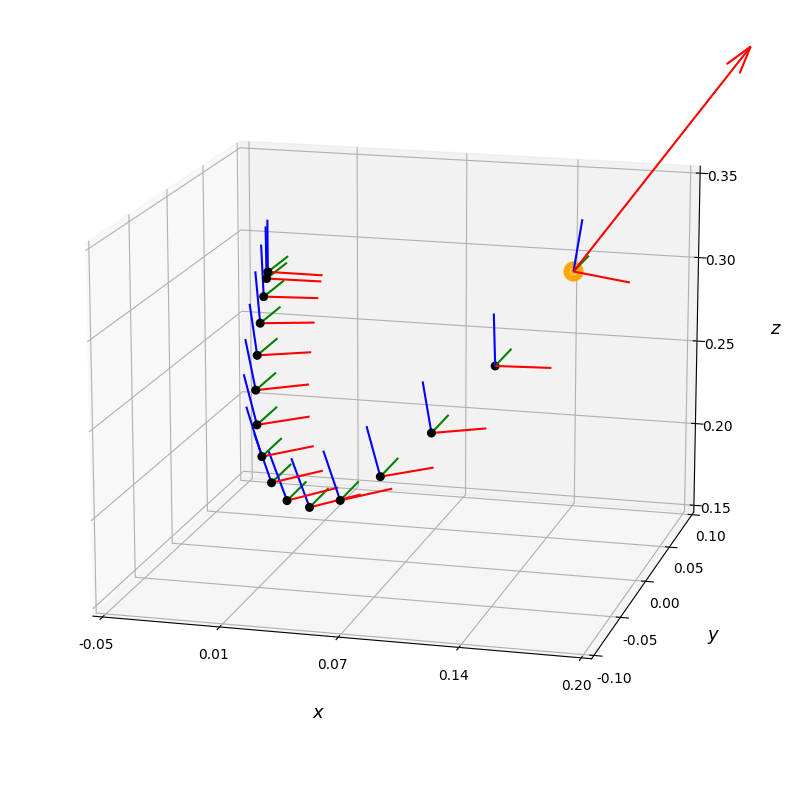

In [49]:
plt.close()


# Increase figure size for a bigger plot area
fig = plt.figure(figsize=(10, 10))  
ax = plt.axes(projection='3d')

# Set the limits to give more room in the plot
ax.set_xlim(-0.05, 0.2)
ax.set_ylim(-0.1, 0.1)
ax.set_zlim(0.15, 0.35)

ax.set_xticks(np.linspace(-0.05, 0.2, 5))  # 5 ticks between -0.5 and 0.5
ax.set_yticks(np.linspace(-0.1, 0.1, 5))  # 5 ticks between -0.5 and 0.5
ax.set_zticks(np.linspace(0.15, 0.35, 5)) 

ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax.set_xlabel("$x$", fontsize=13, labelpad=20)
ax.set_ylabel("$y$", fontsize=13, labelpad=20)
ax.set_zlabel("$z$", fontsize=13, labelpad=20)

i = 0
step_size = 1  # Increase step size to reduce the number of points plotted
draw_l_vel = False
ax.scatter(pos[i][..., 0][:-1], pos[i][..., 1][:-1], pos[i][..., 2][:-1], color='black', linewidths=2, alpha=1)
ax.scatter(trunk_x_lo[i, 0], trunk_x_lo[i, 1], trunk_x_lo[i, 2], alpha=1, linewidths=10, color="orange")

for j in range(0, len(orient[i]), step_size):
    # Getting the current position and orientation
    p = pos[i, j].numpy()
    o = orient[i, j].numpy()

    # Define the Cartesian frame vectors (x, y, z)
    x_vec = np.array([1, 0, 0])  # X-axis
    y_vec = np.array([0, 1, 0])  # Y-axis
    z_vec = np.array([0, 0, 1])  # Z-axis

    # Rotate the frame based on orientation
    rotation_matrix = np.eye(3)
    rotation_matrix = np.matmul(rotation_matrix, np.array([
        [1, 0, 0],
        [0, np.cos(o[0]), -np.sin(o[0])],
        [0, np.sin(o[0]), np.cos(o[0])]
    ]))
    rotation_matrix = np.matmul(rotation_matrix, np.array([
        [np.cos(o[1]), 0, np.sin(o[1])],
        [0, 1, 0],
        [-np.sin(o[1]), 0, np.cos(o[1])]
    ]))
    rotation_matrix = np.matmul(rotation_matrix, np.array([
        [np.cos(o[2]), -np.sin(o[2]), 0],
        [np.sin(o[2]), np.cos(o[2]), 0],
        [0, 0, 1]
    ]))

    x_vec = np.matmul(rotation_matrix, x_vec)
    x_vec /= np.linalg.norm(x_vec)
    y_vec = np.matmul(rotation_matrix, y_vec)
    y_vec /= np.linalg.norm(y_vec)
    z_vec = np.matmul(rotation_matrix, z_vec)
    z_vec /= np.linalg.norm(z_vec)

    # Plotting the frame
    ax.quiver(p[0], p[1], p[2], x_vec[0], x_vec[1], x_vec[2], length=0.03, color='r', arrow_length_ratio=0)
    ax.quiver(p[0], p[1], p[2], y_vec[0], y_vec[1], y_vec[2], length=0.03, color='g', arrow_length_ratio=0)
    ax.quiver(p[0], p[1], p[2], z_vec[0], z_vec[1], z_vec[2], length=0.03, color='b', arrow_length_ratio=0)

# Plot the final linear velocity quiver
ax.quiver(pos[...,-1, 0], pos[...,-1, 1], pos[...,-1, 2], lin_vel[...,-1, 0], lin_vel[...,-1, 1], lin_vel[...,-1, 2], length=0.1, normalize=False, color='red', arrow_length_ratio=0.1)

ax.view_init(15, -75, 0) 

# plt.savefig("fig/bez_no_orientation.pdf", dpi=300)
# plt.savefig("fig/bez_orientation.pdf", dpi=300)
plt.show()


In [50]:
trunk_x_lo = torch.tensor([[0.1319, 0.0000, 0.2560]])
trunk_xd_lo = torch.tensor([[0.7000, 0.0000, 1.3873]])

trunk_x_exp = torch.tensor([[0.1648, 0.0000, 0.3211]])
trunk_xd_exp = torch.tensor([[0.7599, 0.0000, 1.5059]])
t_th = torch.tensor([[0.75,]])
t_exp = torch.tensor([[0.0450,]])
a = torch.tensor([[2.9533,]])

In [51]:
t_tot = t_th + t_exp

In [52]:
t = torch.arange(0,t_exp.item(),0.005)

In [53]:
x_expl = torch.stack([torch.lerp(trunk_x_lo, trunk_x_exp, t_i/t_exp.item()) for t_i in t])
xd_expl = torch.stack([torch.lerp(trunk_xd_lo, trunk_xd_exp, t_i/t_exp.item()) for t_i in t])

In [54]:
x_expl_e =  1/2 * a.item() * t**2 + torch.norm(trunk_xd_lo) * t + torch.norm(trunk_x_lo)
xd_expl_e = torch.norm(trunk_xd_lo) + a.item() * t

In [55]:
x_expl.norm(dim=-1).flatten(),x_expl_e

(tensor([0.2880, 0.2961, 0.3042, 0.3123, 0.3204, 0.3285, 0.3366, 0.3447, 0.3528,
         0.3609]),
 tensor([0.2880, 0.2958, 0.3037, 0.3116, 0.3197, 0.3278, 0.3359, 0.3442, 0.3525,
         0.3609]))

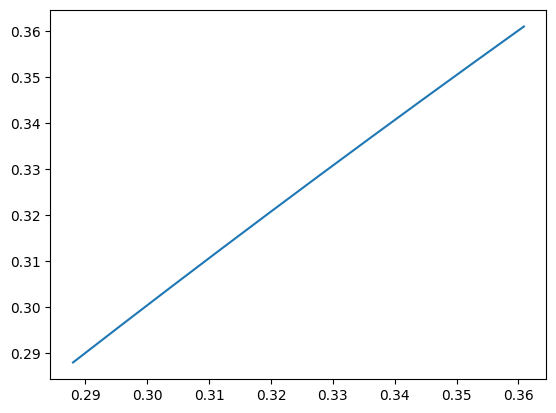

In [56]:
plt.plot(x_expl_e, torch.norm(x_expl, dim=-1))

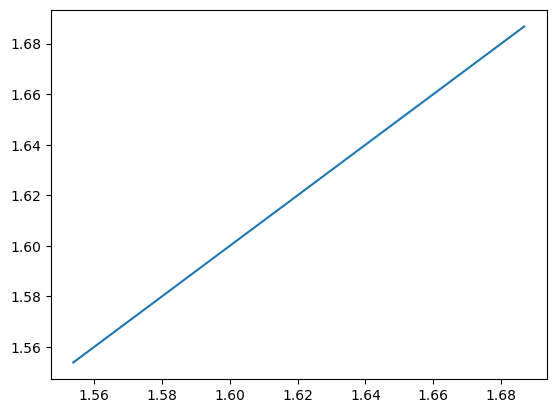

In [57]:
plt.plot(xd_expl_e, torch.norm(xd_expl, dim=-1))

In [58]:
trunk_x_0 = torch.tensor([[0, 0, 0.31]])
trunk_xd_0 = torch.zeros_like(trunk_x_0)

In [59]:
trunk_x_lo = torch.tensor([[0.1362, 0.0000, 0.25]])
trunk_xd_lo = torch.tensor([[0.8, 0.0000, 1.32]])
t_th = torch.tensor([[0.55,]])

In [60]:
k = torch.tensor([[2]])
d = torch.tensor([[0.15]])

In [61]:
trunk_xd_lo_un = trunk_xd_lo / torch.norm(trunk_xd_lo)
trunk_xd_lo_un

tensor([[0.5183, 0.0000, 0.8552]])

In [62]:
trunk_x_exp = trunk_x_lo + (trunk_xd_lo_un * d)
trunk_x_exp

tensor([[0.2139, 0.0000, 0.3783]])

In [63]:
trunk_xd_exp = trunk_xd_lo * k
trunk_xd_exp

tensor([[1.6000, 0.0000, 2.6400]])

In [64]:
trunk_xd_exp.norm()

tensor(3.0870)

In [65]:
vf_n = torch.norm(trunk_xd_exp)
v0_n = torch.norm(trunk_xd_lo)
sf_n = torch.norm(trunk_x_exp)
s0_n = torch.norm(trunk_x_lo)

a = 0.5 * ((torch.pow(vf_n, 2) - torch.pow(v0_n, 2)) / ((sf_n - s0_n) + 1e-15))
a 

tensor(23.8405)

In [66]:
t_exp = ((vf_n - v0_n) / (a + 1e-15))
t_exp

tensor(0.0647)

In [67]:
t_th_total = t_th + t_exp
t_th_total

tensor([[0.6147]])

In [68]:
i = 0

In [69]:
pos_lin_vel_e = [BezierTrajectory(trunk_x_0, trunk_xd_0, trunk_x_lo, trunk_xd_lo, t_th, t) for t in torch.linspace(0, t_th.item(), 40)]
pos_e = torch.stack([val[0] for val in pos_lin_vel_e], dim=1)
lin_vel_e = torch.stack([val[1] for val in pos_lin_vel_e], dim=1)

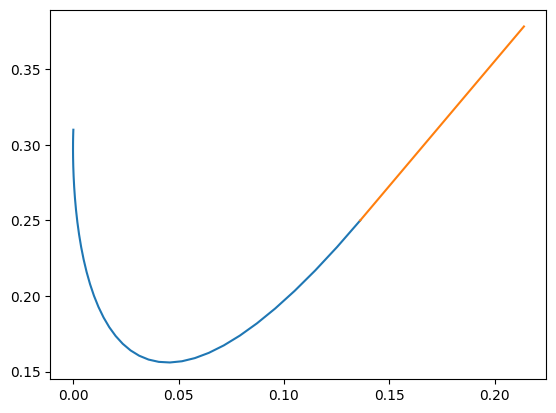

In [70]:
plt.plot(pos_e[i][..., 0],pos_e[i][..., 2])
plt.plot([pos_e[i][..., 0][-1].item(),trunk_x_exp[..., 0].item()],[pos_e[i][..., 2][-1].item(),trunk_x_exp[..., 2].item()])
plt.show()

In [71]:
# # plt.close()

# fig = plt.figure(figsize=(10, 10))
# ax = plt.axes(projection='3d')
# ax.set_zlim(0, 0.4)
# ax.set_xlim(-0.2, 0.2)
# ax.set_ylim(-0.2, 0.2)
# ax.set_xlabel("x")
# ax.set_ylabel("y")
# ax.set_zlabel("z")

# i = 0
# ax.scatter(pos[i][..., 0], pos[i][..., 1], pos[i][..., 2], color='black', linewidths=1, alpha=1)

# ax.scatter(trunk_x_lo[i, 0], trunk_x_lo[i, 1], trunk_x_lo[i, 2], alpha=1, linewidths=5, color="green")

# ax.plot([pos[i][..., 0][-1].item(),trunk_x_exp[..., 0].item()],[pos[i][..., 1][-1].item(),trunk_x_exp[..., 1].item()],[pos[i][..., 2][-1].item(),trunk_x_exp[..., 2].item()], color="black")

# ax.scatter(trunk_x_exp[i, 0], trunk_x_exp[i, 1], trunk_x_exp[i, 2], alpha=1, linewidths=5, color="orange")

# ax.quiver(trunk_x_exp[...,-1, 0], trunk_x_exp[...,-1, 1], trunk_x_exp[...,-1, 2], trunk_xd_exp[...,-1, 0], trunk_xd_exp[...,-1, 1], trunk_xd_exp[...,-1, 2], length=0.1, normalize=False, color='red', arrow_length_ratio=0.1)

# plt.show()

In [72]:
trunk_x_0 = torch.tensor([[0, 0, 0.31]])
trunk_xd_0 = torch.zeros_like(trunk_x_0)

In [73]:
trunk_x_lo = trunk_x_exp
trunk_xd_lo = trunk_xd_exp
t_th = t_th_total

In [74]:
pos_lin_vel = [BezierTrajectory(trunk_x_0, trunk_xd_0, trunk_x_lo, trunk_xd_lo, t_th, t) for t in torch.linspace(0, t_th.item(), 40)]
pos = torch.stack([val[0] for val in pos_lin_vel], dim=1)
lin_vel = torch.stack([val[1] for val in pos_lin_vel], dim=1)

In [75]:
# # plt.close()

# fig = plt.figure(figsize=(10, 10))
# ax = plt.axes(projection='3d')
# ax.set_zlim(0, 0.4)
# ax.set_xlim(-0.2, 0.2)
# ax.set_ylim(-0.2, 0.2)
# ax.set_xlabel("x")
# ax.set_ylabel("y")
# ax.set_zlabel("z")

# i = 0
# ax.scatter(pos[i][..., 0], pos[i][..., 1], pos[i][..., 2], color='black', linewidths=1, alpha=1)

# ax.scatter(trunk_x_lo[i, 0], trunk_x_lo[i, 1], trunk_x_lo[i, 2], alpha=1, linewidths=5, color="orange")

# ax.quiver(pos[...,-1, 0], pos[...,-1, 1], pos[...,-1, 2], lin_vel[...,-1, 0], lin_vel[...,-1, 1], lin_vel[...,-1, 2], length=0.1, normalize=False, color='red', arrow_length_ratio=0.1)

# plt.show()

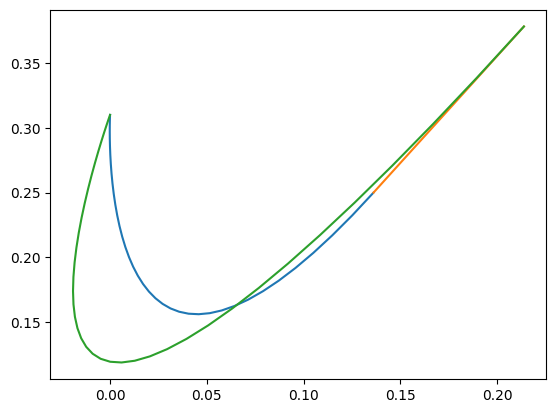

In [76]:
plt.plot(pos_e[i][..., 0],pos_e[i][..., 2])
plt.plot([pos_e[i][..., 0][-1].item(),trunk_x_exp[..., 0].item()],[pos_e[i][..., 2][-1].item(),trunk_x_exp[..., 2].item()])
plt.plot(pos[i][..., 0],pos[i][..., 2])
plt.show()

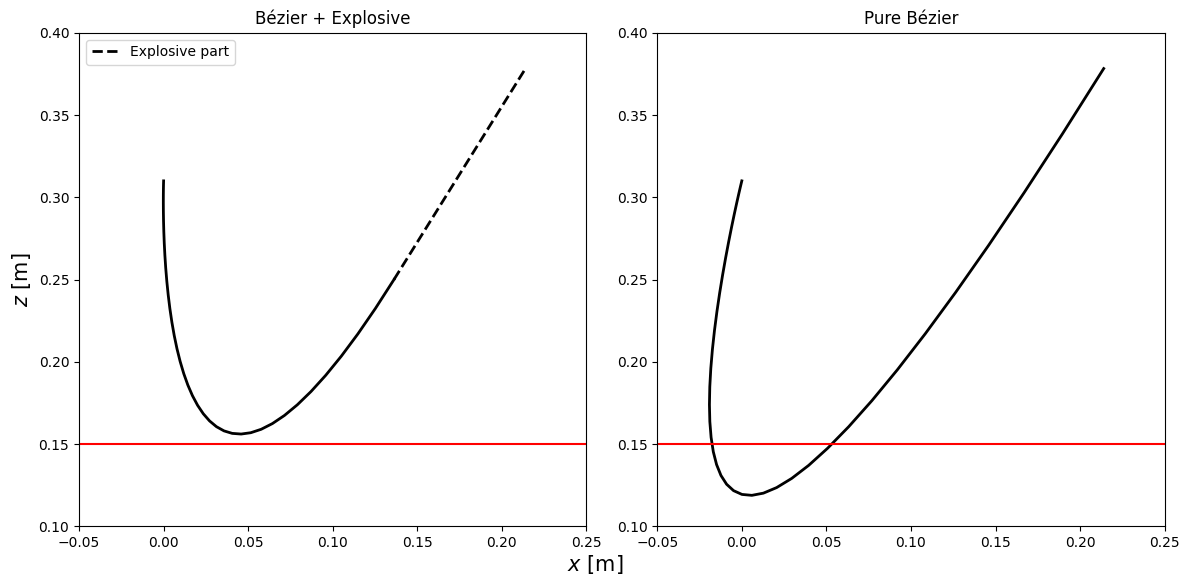

In [77]:
plt.close()

# Create two subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# First subplot for the first trajectory
ax[0].plot(pos_e[i][..., 0], pos_e[i][..., 2], linewidth=2, color="black")
ax[0].plot([pos_e[i][..., 0][-1].item(), trunk_x_exp[..., 0].item()], 
           [pos_e[i][..., 2][-1].item(), trunk_x_exp[..., 2].item()], linewidth=2, color="black", linestyle = '--', label='Explosive part')

# Set labels and title for the first subplot
ax[0].set_ylabel('$z$ [m]', fontsize=15)
ax[0].set_title('Bézier + Explosive')
ax[0].axhline(0.15, color="red")
ax[0].set_xlim(-0.05,0.25)
ax[0].set_ylim(0.1,0.4)

ax[0].legend(loc='upper left')

# Second subplot for the second trajectory
ax[1].plot(pos[i][..., 0], pos[i][..., 2],linewidth=2, color="black")

# Set labels and title for the second subplot
ax[1].set_title('Pure Bézier')
ax[1].axhline(0.15, color="red")
ax[1].set_xlim(-0.05,0.25)
ax[1].set_ylim(0.1,0.4)

fig.text(0.5, 0.04, '$x $ [m]', fontsize=15, ha='center')

# Show the plots
plt.tight_layout(rect=[0, 0.05, 1, 1])   # Adjust layout so titles/labels don't overlap
plt.savefig("fig/explosive.pdf", dpi=300)
plt.show()


In [78]:
trunk_x_lo = trunk_x_exp
trunk_xd_lo = trunk_xd_exp
t_th = t_th_total

In [79]:
trunk_x_0 = torch.tensor([[0, 0, 0.31]])
trunk_xd_0 = torch.zeros_like(trunk_x_0)

trunk_x_lo = torch.tensor([[0.1648, 0.0000, 0.3211]])
trunk_xd_lo = torch.tensor([[0.9, 0.0000, 1.3]])

In [80]:
t_th_values = torch.tensor([[0.5], [0.6], [0.75],[0.9], [1.1]])

In [81]:
# Function that evaluates and returns Bezier position and linear velocity
def compute_bezier_curve(trunk_x_0, trunk_xd_0, trunk_x_lo, trunk_xd_lo, t_th, num_points=40):
    pos_lin_vel = [BezierTrajectory(trunk_x_0, trunk_xd_0, trunk_x_lo, trunk_xd_lo, t_th, t) for t in torch.linspace(0, t_th.item(), num_points)]
    pos = torch.stack([val[0] for val in pos_lin_vel], dim=1)
    return pos

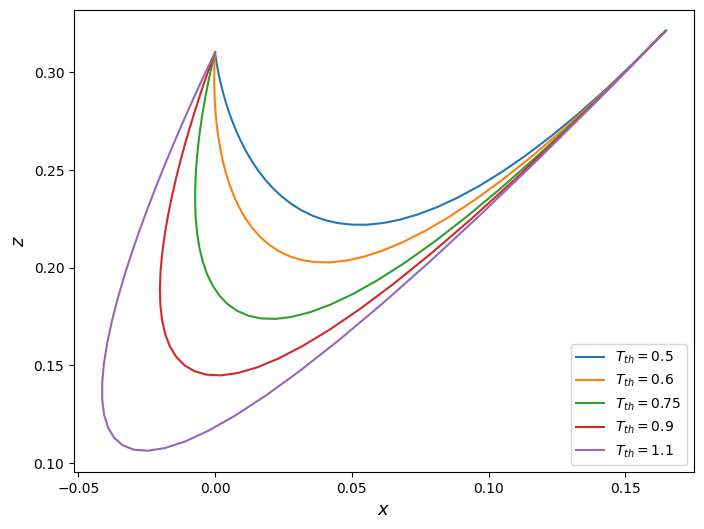

In [82]:
# Create a figure for plotting
plt.figure(figsize=(8, 6))

# Loop through each t_th value, compute the Bézier curve, and plot it
for t_th in t_th_values:
    pos = compute_bezier_curve(trunk_x_0, trunk_xd_0, trunk_x_lo, trunk_xd_lo, t_th)
    
    plt.plot(pos[0][..., 0], pos[0][..., 2], label=f'$T_{{th}} = {round(t_th.item(), 2)}$')

# Adding labels and title to the plot
plt.xlabel('$x$', fontsize=13)
plt.ylabel('$z$', fontsize=13)
plt.legend()
# plt.grid(True)
plt.savefig("fig/bez_t_th.pdf", dpi=300, bbox_inches='tight')
plt.show()